# Data Preparation

## Import Libraries

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import geopandas as gpd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.cluster import KMeans
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.oaxaca import OaxacaBlinder
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")


## Import Dataset

In [ ]:
#Import dataset present on ./data

dt_std_pt = pd.read_csv('./data/students_portugal.csv', sep=';')

#Show the first 5 rows of the dataset
dt_std_pt.head()

,CNTSTUID,CNTSCHID,STRATUM,STU_GENDER,ISCEDP,REPEAT,EXERPRAC,RELATST,BULLIED,FAMSUP,...,PV1CRTH_NC,PV2CRTH_NC,PV3CRTH_NC,PV4CRTH_NC,PV5CRTH_NC,PV6CRTH_NC,PV7CRTH_NC,PV8CRTH_NC,PV9CRTH_NC,PV10CRTH_NC
0,62050001.0,62000159.0,PRT15,1.0,244.0,1.0,6.0,0.1469,1.1953,0.0332,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,62050002.0,62000170.0,PRT09,2.0,344.0,0.0,5.0,0.2898,-1.2280,-0.2763,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,62050003.0,62000004.0,PRT07,1.0,244.0,1.0,2.0,-0.5679,0.6699,1.7153,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,62050005.0,62000044.0,PRT10,1.0,344.0,0.0,1.0,2.2513,-1.2280,-0.6200,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,62050007.0,62000001.0,PRT08,2.0,344.0,0.0,10.0,2.9152,0.1107,-0.0578,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Quality and Validation of Data

In [24]:
# ver estudantes duplicados
count = dt_std_pt[dt_std_pt.duplicated(keep=False)].shape[0]
count

0

In [25]:
# ver nulos
dt_std_pt.isnull().sum()
# mostrar todas as colunas com nulos
count = dt_std_pt.isnull().sum()[dt_std_pt.isnull().sum() > 0]
print(f"Nº de colunas com nulos: {count.shape[0]}")

Nº de colunas com nulos: 40


In [26]:
#nº de colunas com +50% de nulos
count = dt_std_pt.isnull().sum()[dt_std_pt.isnull().sum() > (dt_std_pt.shape[0] * 0.33)]    # 1/3 de nulos
print(f"Nº de colunas com +33% de nulos: {count.shape[0]}")
count

Nº de colunas com +33% de nulos: 20


,0
PV1FLIT,6793
PV2FLIT,6793
PV3FLIT,6793
PV4FLIT,6793
PV5FLIT,6793
PV6FLIT,6793
PV7FLIT,6793
PV8FLIT,6793
PV9FLIT,6793
PV10FLIT,6793


#### Spearman Correlation between Variables

<Axes: >

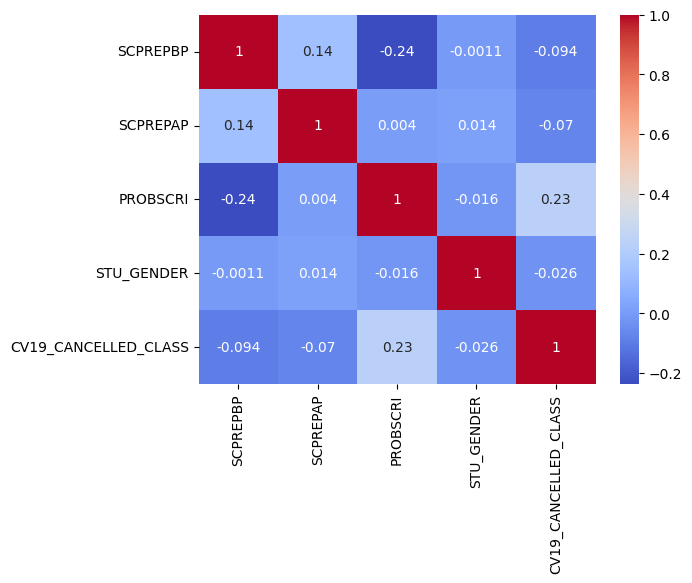

In [27]:
# correlação entre GRADE,ESCS e HISCED com spearman

sns.heatmap(dt_std_pt[["SCPREPBP", "SCPREPAP", "PROBSCRI", "STU_GENDER", "CV19_CANCELLED_CLASS"]].corr(method='spearman'), annot=True, cmap="coolwarm")

In [28]:
# correlação entre idade do prof e anos de experiência com spearman
cols_modelo = [
    'STU_GENDER', 'ISCEDP', 'REPEAT',
    'EXERPRAC', 'RELATST', 'BULLIED', 'FAMSUP', 'HISCED', 'ICTRES', 'ESCS',
    'SCHLTYPE', 'SCHSIZE', 'TOTAT', 'PROATCE', 'STRATIO', 'STAFFSHORT',
    'EDUSHORT', 'SCPREPBP', 'SCPREPAP', 'PROBSCRI', 'CV19_ONLINE_CLASS',
    'CV19_CANCELLED_CLASS', 'TC_GENDER_MEAN', 'TC_AGE_MEAN', 'TC_EXP_MEAN',
    'TC_PERM_PERC'
]

dt_std_pt[cols_modelo].corr(method='spearman')

,STU_GENDER,ISCEDP,REPEAT,EXERPRAC,RELATST,BULLIED,FAMSUP,HISCED,ICTRES,ESCS,...,EDUSHORT,SCPREPBP,SCPREPAP,PROBSCRI,CV19_ONLINE_CLASS,CV19_CANCELLED_CLASS,TC_GENDER_MEAN,TC_AGE_MEAN,TC_EXP_MEAN,TC_PERM_PERC
STU_GENDER,1.000000,0.024339,0.077427,0.266243,-0.022696,0.011601,-0.097793,0.019043,0.027933,0.002612,...,-0.015309,-0.001065,0.014454,-0.016127,0.007640,-0.026100,0.002146,-0.015974,-0.017953,0.019689
ISCEDP,0.024339,1.000000,-0.656108,-0.045536,0.025656,-0.097289,0.026678,0.001447,0.095331,0.071473,...,-0.101270,0.045391,-0.033905,-0.185494,0.015977,-0.004461,0.045679,-0.079531,-0.078876,-0.038414
REPEAT,0.077427,-0.656108,1.000000,0.094433,-0.050853,0.133723,-0.081393,-0.152496,-0.133962,-0.255356,...,0.087255,-0.006368,0.036442,0.122212,-0.000740,0.008465,0.028561,-0.041879,-0.053664,-0.041255
EXERPRAC,0.266243,-0.045536,0.094433,1.000000,-0.035593,0.017410,0.041526,0.070138,0.095079,0.063887,...,-0.007816,-0.010049,0.015224,-0.002988,0.019526,-0.033532,0.014225,-0.019634,-0.017226,-0.007270
RELATST,-0.022696,0.025656,-0.050853,-0.035593,1.000000,-0.200440,0.202241,-0.007237,0.006590,0.012182,...,-0.039875,0.020326,0.022333,-0.062578,0.018258,-0.013284,0.035396,-0.066039,-0.046606,0.008441
BULLIED,0.011601,-0.097289,0.133723,0.017410,-0.200440,1.000000,-0.155608,0.030305,-0.038051,-0.007991,...,0.009063,-0.005263,-0.001672,0.039903,0.005579,0.003996,0.010801,-0.021313,-0.038966,-0.001146
FAMSUP,-0.097793,0.026678,-0.081393,0.041526,0.202241,-0.155608,1.000000,0.018291,0.082625,0.061039,...,0.011082,0.007607,0.012895,0.027050,0.011615,0.016191,-0.008548,0.021311,0.040821,0.021292
HISCED,0.019043,0.001447,-0.152496,0.070138,-0.007237,0.030305,0.018291,1.000000,0.238055,0.830074,...,-0.025969,0.002124,-0.045123,-0.074272,0.042422,-0.036492,-0.005252,0.014898,-0.008243,0.039547
ICTRES,0.027933,0.095331,-0.133962,0.095079,0.006590,-0.038051,0.082625,0.238055,1.000000,0.477295,...,-0.035643,0.014917,0.007988,-0.072443,0.034792,-0.026987,-0.023900,0.012167,0.030965,0.046460
ESCS,0.002612,0.071473,-0.255356,0.063887,0.012182,-0.007991,0.061039,0.830074,0.477295,1.000000,...,-0.045742,0.019623,-0.052101,-0.108975,0.044376,-0.031401,-0.011983,0.026535,0.016923,0.063089


In [29]:
dt_std_pt[['TOTAT','SCHSIZE','STRATIO']].corr(method='spearman')

,TOTAT,SCHSIZE,STRATIO
TOTAT,1.000000,0.805006,-0.252747
SCHSIZE,0.805006,1.000000,0.247257
STRATIO,-0.252747,0.247257,1.000000


## Data Preparation for Modeling

In [30]:
dt_std_pt.drop(columns=["TC_EXP_MEAN", "ISCEDP", "HISCED","SCHSIZE"], inplace=True)

In [31]:
mapa_regioes_prt = {
    'PRT01': 'Alentejo Central', 'PRT02': 'Alentejo Litoral', 'PRT03': 'Algarve',
    'PRT04': 'Alto Alentejo', 'PRT05': 'Alto Minho', 'PRT06': 'Alto Tâmega',
    'PRT07': 'AM Lisboa', 'PRT08': 'AM Porto', 'PRT09': 'Ave',
    'PRT10': 'Baixo Alentejo', 'PRT11': 'Beira Baixa', 'PRT12': 'Beiras e Serra da Estrela',
    'PRT13': 'Cávado', 'PRT14': 'Douro', 'PRT15': 'Lezíria do Tejo',
    'PRT16': 'Médio Tejo', 'PRT17': 'Oeste', 'PRT18': 'R.A. Madeira',
    'PRT19': 'R.A. Açores', 'PRT20': 'Região de Aveiro', 'PRT21': 'Região de Coimbra',
    'PRT22': 'Região de Leiria', 'PRT23': 'Tâmega e Sousa', 'PRT24': 'Terras de Trás-os-Montes',
    'PRT25': 'Viseu Dão Lafões'
}

dt_std_pt["STRATUM"] = dt_std_pt["STRATUM"].map(mapa_regioes_prt)

In [32]:
mapa_macro = {
    # Norte
    'Alto Minho': 'Norte',
    'Cávado': 'Norte',
    'Ave': 'Norte',
    'Tâmega e Sousa': 'Norte',
    'Douro': 'Norte',
    'Terras de Trás-os-Montes': 'Norte',
    'Alto Tâmega': 'Norte',

    # Centro
    'Região de Aveiro': 'Centro',
    'Região de Coimbra': 'Centro',
    'Região de Leiria': 'Centro',
    'Viseu Dão Lafões': 'Centro',
    'Beira Baixa': 'Centro',
    'Beiras e Serra da Estrela': 'Centro',
    'Oeste': 'Centro',
    'Médio Tejo': 'Centro',

    # Lisboa
    'AM Lisboa': 'Lisboa',
    'Lezíria do Tejo': 'Lisboa',

    # Sul (Alentejo+Algarve)
    'Alto Alentejo': 'Sul',
    'Alentejo Central': 'Sul',
    'Alentejo Litoral': 'Sul',
    'Baixo Alentejo': 'Sul',
    'Algarve': 'Sul',

    # Porto (separado)
    'AM Porto': 'Porto',

    # Algarve
    #'Algarve': 'Algarve',

    # Ilhas
    'R.A. Madeira': 'Ilhas',
    'R.A. Açores': 'Ilhas'
}

dt_std_pt["REGIAO"] = dt_std_pt["STRATUM"].map(mapa_macro)


In [33]:
len(dt_std_pt.columns)

56

## Modeling

### Oaxaca-Blinder

In [34]:
pv_cols = [f"PV{i}MATH" for i in range(1, 11)]

X_base = [  'STU_GENDER', 'REPEAT','EXERPRAC', 'RELATST', 'BULLIED',
           'FAMSUP', 'ICTRES', 'ESCS', 'SCHLTYPE', 'TOTAT', # 'SCHSIZE',
            'PROATCE', 'STRATIO', 'STAFFSHORT', 'EDUSHORT', 'SCPREPBP',
            'SCPREPAP', 'PROBSCRI', 'CV19_ONLINE_CLASS','CV19_CANCELLED_CLASS',
            'TC_GENDER_MEAN', 'TC_AGE_MEAN', 'TC_PERM_PERC'
]

### Auxiliary Functions

In [35]:
def plot_diference(df_resultados=None):
    df_res = df_resultados.copy()
    df_res["Par"] = df_res["Região A"] + " → " + df_res["Região B"]
    df_res = df_res.sort_values("Gap total", ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # gráfico 1: gap total
    cores_gap = ["#185FA5" if g >= 0 else "#A32D2D" for g in df_res["Gap total"]]
    axes[0].barh(df_res["Par"], df_res["Gap total"], color=cores_gap)
    axes[0].axvline(0, color="black", linewidth=0.8, linestyle="--")
    axes[0].set_xlabel("Pontos PISA", fontsize=11)
    axes[0].set_title("Gap total por par de regiões", fontsize=13, fontweight="bold")
    axes[0].tick_params(axis="y", labelsize=9)

    #  gráfico 2: explained vs unexplained
    y = np.arange(len(df_res))
    height = 0.4

    axes[1].barh(y + height/2, df_res["Explained"], height=height, color="#185FA5", label="Explained (dotações)")
    axes[1].barh(y - height/2, df_res["Unexplained"], height=height, color="#D85A30", label="Unexplained (estrutural)")
    axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")
    axes[1].set_yticks(y)
    axes[1].set_yticklabels(df_res["Par"], fontsize=9)
    axes[1].set_xlabel("Pontos PISA", fontsize=11)
    axes[1].set_title("Explained vs Unexplained por par", fontsize=13, fontweight="bold")
    axes[1].legend(fontsize=10)

    plt.tight_layout()
    #plt.savefig("oaxaca_resultados.png", dpi=150, bbox_inches="tight")
    plt.show()

In [36]:
def oaxaca_table(df_resultados=None):
    fig2, ax = plt.subplots(figsize=(8, 7))
    ax.axis("off")

    df_tabela = df_resultados.copy()
    df_tabela["Par"] = df_tabela["Região A"] + " → " + df_tabela["Região B"]
    df_tabela = df_tabela.sort_values("Gap total", ascending=False)[["Par", "Explained", "Unexplained", "Gap total"]]
    df_tabela[["Explained", "Unexplained", "Gap total"]] = df_tabela[["Explained", "Unexplained", "Gap total"]].round(2)

    tabela = ax.table(
        cellText=df_tabela.values,
        colLabels=["Par", "Explained", "Unexplained", "Gap total"],
        cellLoc="center",
        loc="center"
    )

    tabela.auto_set_font_size(False)
    tabela.set_fontsize(10)
    tabela.scale(1.2, 1.6)

    # cabeçalho
    for j in range(4):
        tabela[0, j].set_facecolor("#185FA5")
        tabela[0, j].set_text_props(color="white", fontweight="bold")

    # linhas alternadas
    for i in range(1, len(df_tabela) + 1):
        for j in range(4):
            tabela[i, j].set_facecolor("#f0f4f8" if i % 2 == 0 else "white")

    plt.tight_layout()
    #plt.savefig("oaxaca_tabela.png", dpi=150, bbox_inches="tight")
    plt.show()

In [37]:
def detailed_result(group_col=None, pares=None, X_cols=None,pv_cols=None):
    resultados_detail_reg = []

    for region_A, region_B in pares:

        df_par = dt_std_pt.copy()
        df_par = df_par[df_par[group_col].isin([region_A, region_B])]
        df_par["female"] = (df_par["STU_GENDER"] == 1).astype(int)
        df_par["group_bin"] = (df_par[group_col] == region_B).astype(int)
        df_par = df_par.dropna(subset=X_cols + pv_cols + [group_col]).copy()

        detail_explained   = None
        detail_unexplained = None

        for pv in pv_cols:
            df_clean = df_par[X_cols + ["group_bin", pv]].apply(pd.to_numeric, errors="coerce").dropna()

            X = sm.add_constant(df_clean[X_cols])
            y = df_clean[pv]
            group = df_clean["group_bin"]

            # separar os dois grupos
            X_A = X[group == 0]
            y_A = y[group == 0]
            X_B = X[group == 1]
            y_B = y[group == 1]

            # regressão separada para cada grupo
            coef_A = sm.OLS(y_A, X_A).fit().params
            coef_B = sm.OLS(y_B, X_B).fit().params

            # médias das características
            mean_A = X_A.mean()
            mean_B = X_B.mean()

            # decomposição detalhada
            explained   = (mean_A - mean_B) * coef_B
            unexplained = mean_B * (coef_A - coef_B)

            if detail_explained is None:
                detail_explained   = explained
                detail_unexplained = unexplained
            else:
                detail_explained   += explained
                detail_unexplained += unexplained

        detail_explained   /= len(pv_cols)
        detail_unexplained /= len(pv_cols)

        for var in detail_explained.index:
            resultados_detail_reg.append({
                "Região A":    region_A,
                "Região B":    region_B,
                "Variável":    var,
                "Explained":   round(detail_explained[var], 3),
                "Unexplained": round(detail_unexplained[var], 3),
            })

    df_detail = pd.DataFrame(resultados_detail_reg)

    # ranking médio entre todos os pares
    resumo = (df_detail.groupby("Variável")[["Explained","Unexplained"]]
                    .mean()
                    .abs()
                    .sort_values("Explained", ascending=False))



    plt.figure(figsize=(10, 6))
    resumo["Explained"].sort_values().plot(kind="barh")

    plt.title("Contribuição Explained por Variável")
    plt.xlabel("Valor Explained")
    plt.ylabel("Variável")
    plt.grid(axis="x", linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.show()

    return resumo

In [38]:
def run_model(group_col=None, X_cols=None, pv_cols=None, pares=None):

    resultados = []

    for region_A, region_B in pares:

        df_par = dt_std_pt.copy()
        df_par = df_par[df_par[group_col].isin([region_A, region_B])]

        df_par["female"] = (df_par["STU_GENDER"] == 1).astype(int)

        df_par["group_bin"] = (df_par[group_col] == region_B).astype(int)
        df_par = df_par.dropna(subset=X_cols + pv_cols + [group_col]).copy()

        explained_list = []
        unexplained_list = []

        for pv in pv_cols:
            X = df_par[X_cols + ["group_bin"]].apply(pd.to_numeric, errors="coerce").astype(float)
            X = sm.add_constant(X)
            y = df_par[pv].astype(float)

            mask = X.notna().all(axis=1) & y.notna()
            X = X[mask]
            y = y[mask]

            model = OaxacaBlinder(y, X, bifurcate="group_bin", hasconst=True)
            res = model.two_fold()
            explained, unexplained, gap = res.params

            explained_list.append(explained)
            unexplained_list.append(unexplained)

        resultados.append({
            "Região A": region_A,
            "Região B": region_B,
            "Explained": round(np.mean(explained_list), 3),
            "Unexplained": round(np.mean(unexplained_list), 3),
            "Gap total": round(np.mean(explained_list) + np.mean(unexplained_list), 3)
        })

    df_resultados = pd.DataFrame(resultados)
    return df_resultados


### Results (Oaxaca - Blinder)
#### By Region

In [39]:
df = dt_std_pt.copy()

group_col_reg = "REGIAO"

# caso se queira comparar apenas pares de regiões
region_A = "Porto"
region_B = "Lisboa"


# filtrar regiões
df = df[df[group_col_reg].isin([region_A, region_B])]

# recodificação manual
#df["female"] = (df["STU_GENDER"] == 1).astype(int)

#dummy_cols = ["female"]

X_cols = X_base

# criar grupo binário
df["group_bin"] = (df[group_col_reg] == region_B).astype(int)

# limpar NA
df_model = df.dropna(subset=X_cols + pv_cols + [group_col_reg]).copy()

regioes = dt_std_pt[group_col_reg].unique()
pares = list(combinations(regioes, 2))

In [40]:
df_resultados_reg = run_model(group_col=group_col_reg,X_cols=X_cols,pv_cols=pv_cols,pares=pares)
print(df_resultados_reg)

   Região A Região B  Explained  Unexplained  Gap total
0    Lisboa    Norte     -3.404       16.485     13.080
1    Lisboa      Sul     -0.529       17.383     16.854
2    Lisboa    Porto      1.111       -0.223      0.889
3    Lisboa   Centro      6.295        0.019      6.314
4    Lisboa    Ilhas    -13.158       28.059     14.901
5     Norte      Sul      3.262        0.512      3.774
6     Norte    Porto      6.701        6.819     13.520
7     Norte   Centro     10.705        8.690     19.395
8     Norte    Ilhas     -2.956        4.784      1.828
9       Sul    Porto      5.580       11.714     17.293
10      Sul   Centro     14.000        9.168     23.168
11      Sul    Ilhas    -17.452       19.507      2.055
12    Porto   Centro      8.576       -2.701      5.875
13    Porto    Ilhas      0.744       14.596     15.340
14   Centro    Ilhas     29.072       -7.857     21.215


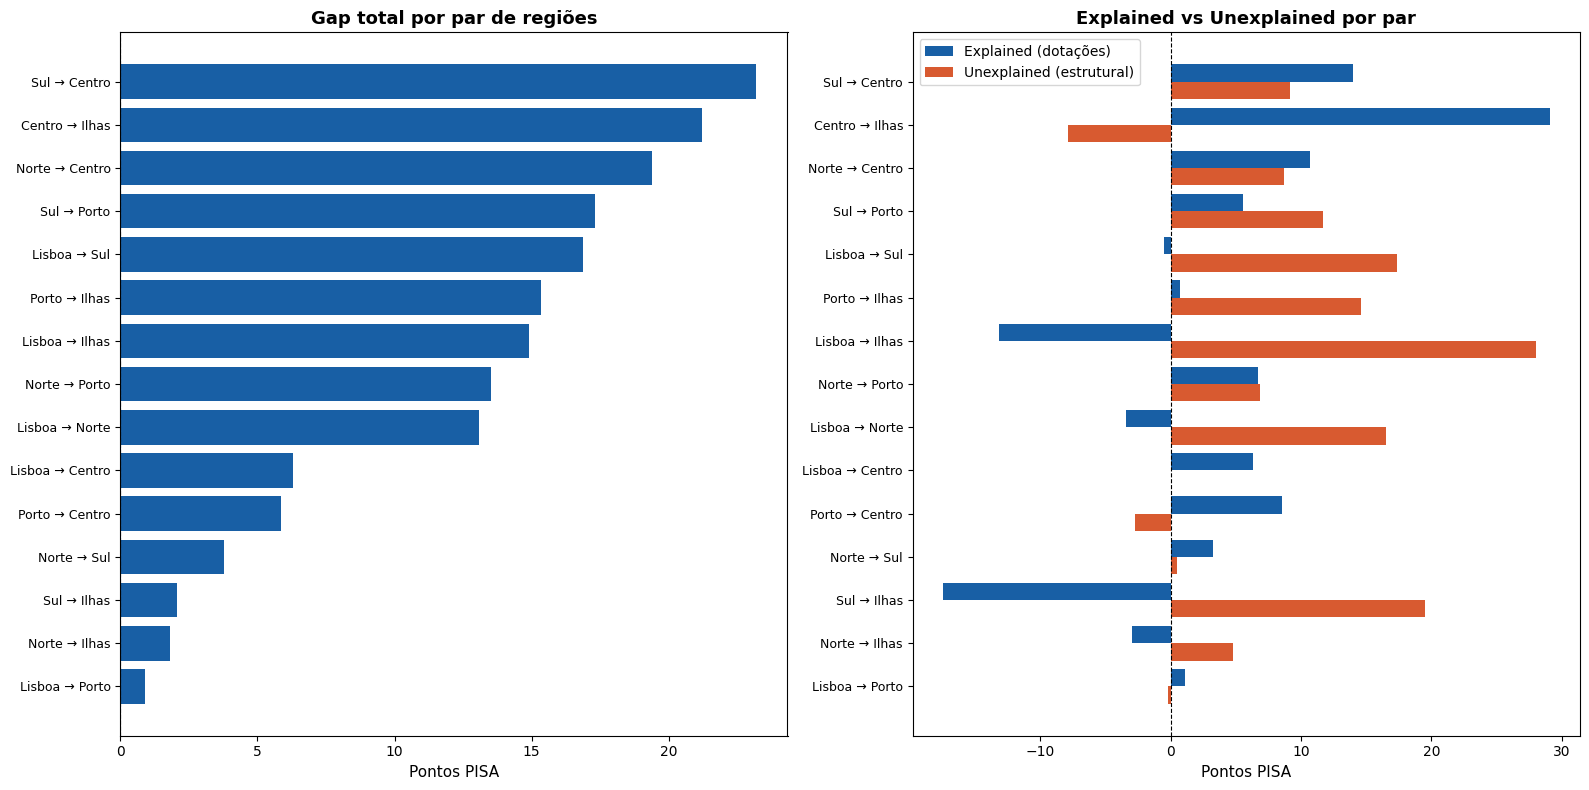

In [41]:
plot_diference(df_resultados=df_resultados_reg)

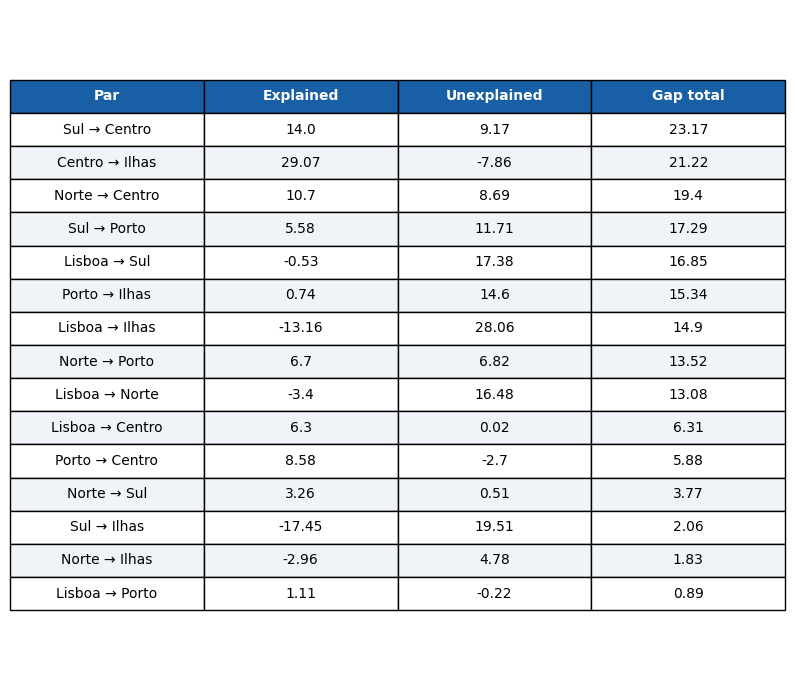

In [42]:
oaxaca_table(df_resultados=df_resultados_reg)

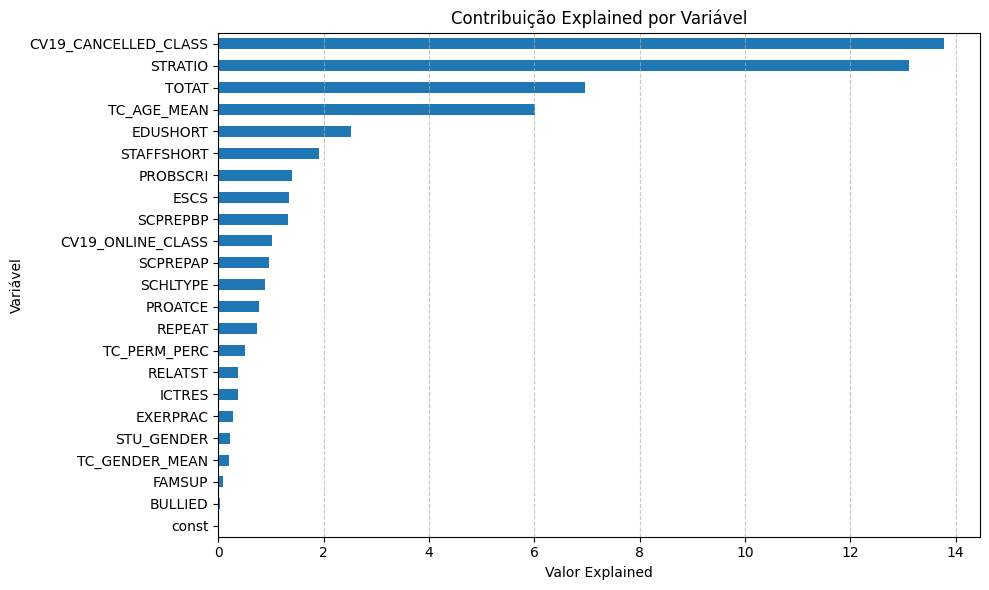

                      Explained  Unexplained
Variável                                    
CV19_CANCELLED_CLASS  13.775267     0.551800
STRATIO               13.125133    36.894600
TOTAT                  6.963267    36.786133
TC_AGE_MEAN            6.018133    41.890400
EDUSHORT               2.511600     4.376533
STAFFSHORT             1.917333     0.337467
PROBSCRI               1.394533     0.643467
ESCS                   1.348600     0.665600
SCPREPBP               1.323067     1.282667
CV19_ONLINE_CLASS      1.012067    37.518533
SCPREPAP               0.964067     3.695067
SCHLTYPE               0.881267    22.579333
PROATCE                0.775600     0.019533
REPEAT                 0.732000     0.406000
TC_PERM_PERC           0.501867     4.415467
RELATST                0.375333     0.336200
ICTRES                 0.373800     0.118867
EXERPRAC               0.283467     3.733000
STU_GENDER             0.230133     3.512467
TC_GENDER_MEAN         0.212000    21.259800
FAMSUP    

In [43]:
resumo_reg = detailed_result(group_col=group_col_reg,pares=pares,X_cols=X_cols,pv_cols=pv_cols)

print(resumo_reg)

### By Sub-Region

In [44]:
df = dt_std_pt.copy()

group_col_stratum = "STRATUM"

# filtrar regiões
df = df[df[group_col_stratum].isin([region_A, region_B])]

# recodificação manual
df["female"] = (df["STU_GENDER"] == 1).astype(int)

dummy_cols = ["female"]

X_cols = X_base + dummy_cols

# criar grupo binário
df["group_bin"] = (df[group_col_stratum] == region_B).astype(int)

# limpar NA
df_model = df.dropna(subset=X_cols + pv_cols + [group_col_stratum]).copy()

regioes = dt_std_pt[group_col_stratum].unique()
pares = list(combinations(regioes, 2))

In [45]:
df_resultados_stratum = run_model(group_col=group_col_stratum,X_cols=X_cols,pv_cols=pv_cols,pares=pares,)
print(df_resultados_stratum)

                     Região A          Região B  Explained  Unexplained  \
0             Lezíria do Tejo               Ave     -3.323        6.449   
1             Lezíria do Tejo         AM Lisboa     -4.432       18.984   
2             Lezíria do Tejo    Baixo Alentejo     -5.495       28.263   
3             Lezíria do Tejo          AM Porto      8.917        4.667   
4             Lezíria do Tejo  Região de Aveiro     21.290        5.166   
..                        ...               ...        ...          ...   
295  Terras de Trás-os-Montes        Alto Minho     -4.429       61.219   
296  Terras de Trás-os-Montes       Beira Baixa     -2.492       81.445   
297                Médio Tejo        Alto Minho    -11.830       16.858   
298                Médio Tejo       Beira Baixa     17.832       -0.697   
299                Alto Minho       Beira Baixa     -1.317       23.481   

     Gap total  
0        3.127  
1       14.552  
2       22.768  
3       13.584  
4       26.456

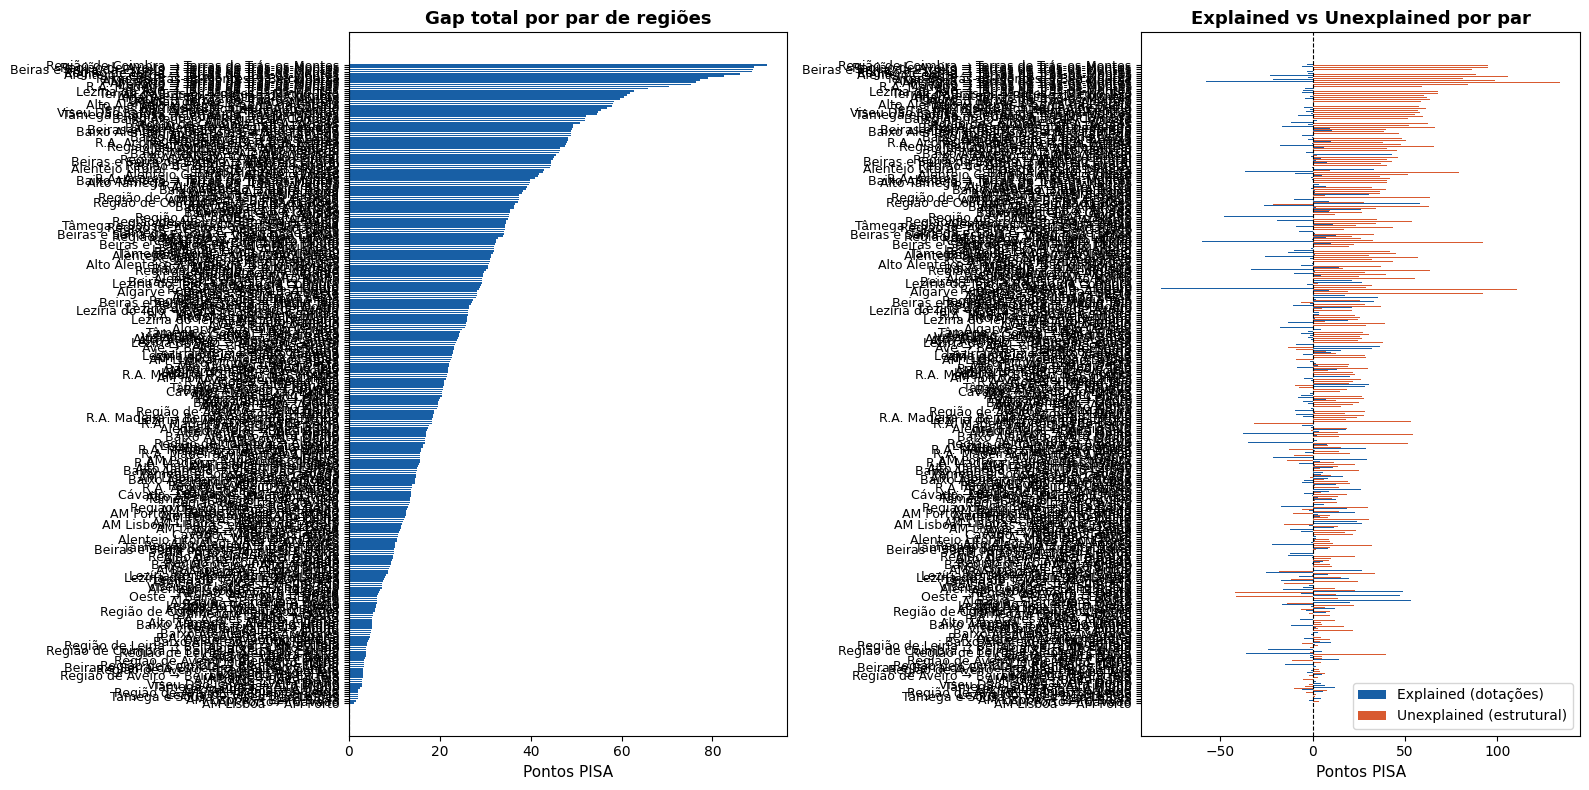

In [46]:
plot_diference(df_resultados=df_resultados_stratum)

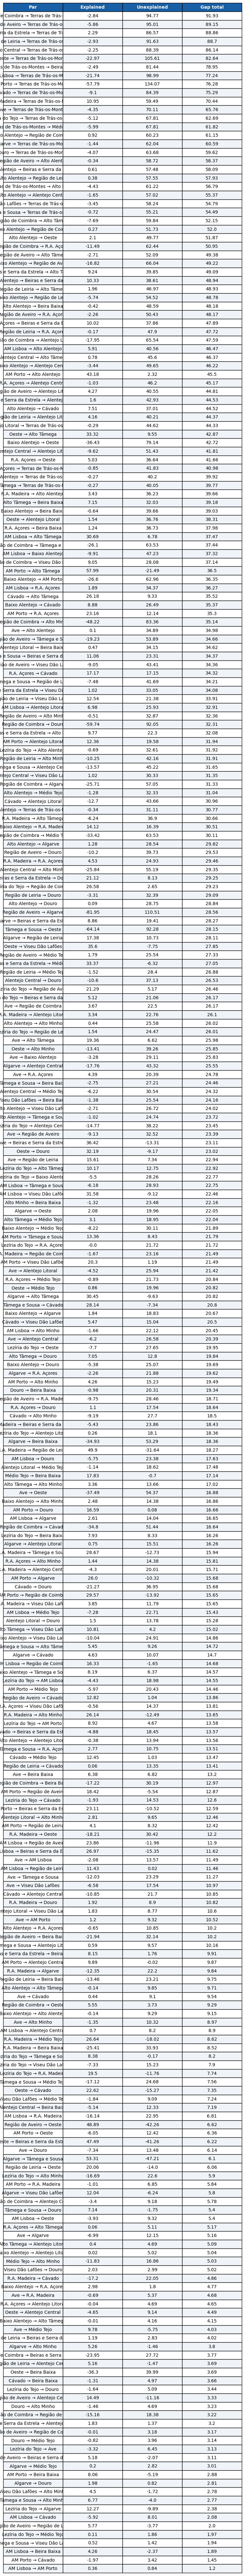

In [47]:
oaxaca_table(df_resultados=df_resultados_stratum)

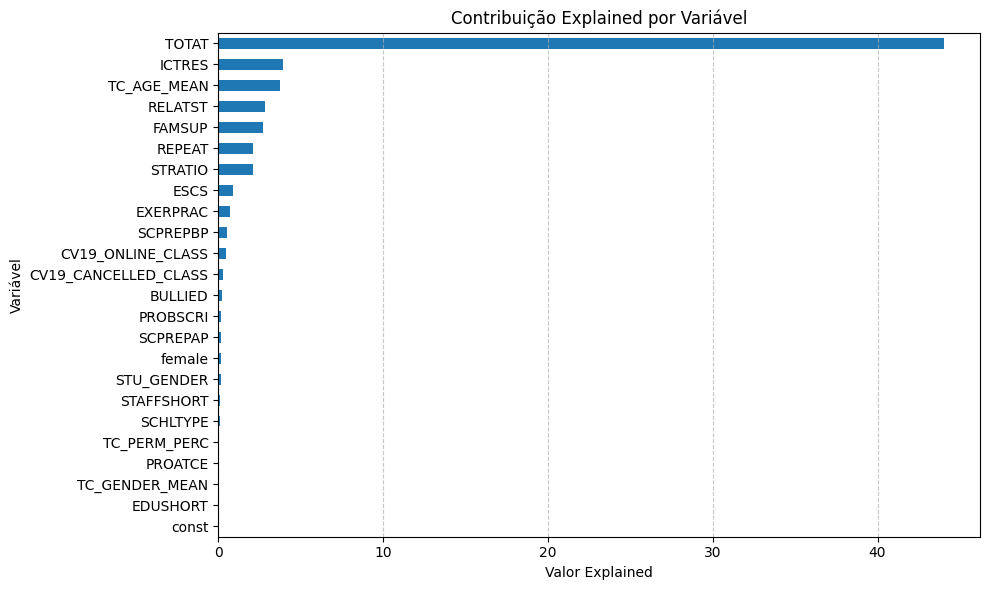

                      Explained  Unexplained
Variável                                    
TOTAT                 44.016163    24.571850
ICTRES                 3.925383     4.413877
TC_AGE_MEAN            3.744570    56.966190
RELATST                2.845837     3.349130
FAMSUP                 2.700937     1.942700
REPEAT                 2.136843     0.025110
STRATIO                2.117397     9.545320
ESCS                   0.902793     2.788200
EXERPRAC               0.736093     1.695290
SCPREPBP               0.519620     0.006917
CV19_ONLINE_CLASS      0.459797     9.865420
CV19_CANCELLED_CLASS   0.309640    12.787467
BULLIED                0.256147     0.820250
PROBSCRI               0.172677     0.014310
SCPREPAP               0.170560     0.193703
female                 0.167813    12.703323
STU_GENDER             0.149990    29.955737
STAFFSHORT             0.116740     0.371440
SCHLTYPE               0.081963     1.945243
TC_PERM_PERC           0.069983     3.005370
PROATCE   

In [48]:
resumo_stratum = detailed_result(group_col=group_col_stratum,pares=pares,X_cols=X_cols,pv_cols=pv_cols)

print(resumo_stratum)

## Modeling

### Clustering
#### Auxiliary Functions

In [49]:
def  evaluate_best_k(df_cluster_raw=None, X_cluster=None):
    inertias, sil_scores = [], []
    K_range = range(2, min(len(df_cluster_raw), 8))  # máx 7 ou nº de zonas - 1

    for k in K_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_cluster)
        inertias.append(km.inertia_)
        sil_scores.append(silhouette_score(X_cluster, labels))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(list(K_range), inertias, marker="o")
    axes[0].set_title("Elbow — Inércia")
    axes[0].set_xlabel("K"); axes[0].set_ylabel("Inércia")

    axes[1].plot(list(K_range), sil_scores, marker="o", color="darkorange")
    axes[1].set_title("Silhouette Score")
    axes[1].set_xlabel("K"); axes[1].set_ylabel("Score")

    plt.tight_layout()
    plt.show()

    best_k = list(K_range)[sil_scores.index(max(sil_scores))]
    print(f"K sugerido pelo Silhouette: {best_k}")

In [50]:
def cluster_profile(df_cluster_raw=None,top_vars=None):
    cluster_profile = df_cluster_raw.groupby("Cluster")[top_vars].mean()

    plt.figure(figsize=(14, 4))
    sns.heatmap(
        cluster_profile.T,
        annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5,
        cbar_kws={"label": "Média (original)"}
    )
    plt.title("Perfil médio das variáveis por Cluster")
    plt.tight_layout()
    plt.show()

In [51]:
def pca_graphic(df_cluster_raw=None, X_cluster=None):
# PCA para 2D
    pca = PCA(n_components=2)
    coords = pca.fit_transform(X_cluster)

    fig, ax = plt.subplots(figsize=(12, 7))

    colors = ["steelblue", "darkorange", "seagreen", "crimson", "purple", "brown"]
    cluster_labels = df_cluster_raw["Cluster"].values

    for i, (x, y, label, cluster) in enumerate(zip(coords[:, 0], coords[:, 1],
                                                    df_cluster_raw.index, cluster_labels)):
        ax.scatter(x, y, color=colors[cluster], s=80, zorder=3)
        ax.annotate(label, (x, y), textcoords="offset points",
                    xytext=(6, 4), fontsize=8.5)

    # legenda
    patches = [mpatches.Patch(color=colors[c], label=f"Cluster {c}")
            for c in sorted(df_cluster_raw["Cluster"].unique())]
    ax.legend(handles=patches, fontsize=10)

    var_explained = pca.explained_variance_ratio_
    ax.set_xlabel(f"PC1 ({var_explained[0]:.1%} variância explicada)")
    ax.set_ylabel(f"PC2 ({var_explained[1]:.1%} variância explicada)")
    ax.set_title("Clustering de Sub-regiões — PCA 2D")
    ax.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

## Results
### By Region

In [52]:


#  Top N variáveis por |Explained| médio (excluindo constante e group_bin)
TOP_N = 10

top_vars = (
    resumo_reg
    .drop(index=["const", "group_bin"], errors="ignore")
    .sort_values("Explained", ascending=False)
    .head(TOP_N)
    .index.tolist()
)
print("Variáveis usadas no clustering:", top_vars)

Variáveis usadas no clustering: ['CV19_CANCELLED_CLASS', 'STRATIO', 'TOTAT', 'TC_AGE_MEAN', 'EDUSHORT', 'STAFFSHORT', 'PROBSCRI', 'ESCS', 'SCPREPBP', 'CV19_ONLINE_CLASS']


In [53]:
# garantir que 'female' existe no dt_std_pt
dt_std_pt["female"] = (dt_std_pt["STU_GENDER"] == 1).astype(int)

#  Médias das top variáveis por Zona (usar dt_std_pt completo)
df_cluster_reg = (
    dt_std_pt
    .dropna(subset=top_vars + [group_col_reg])
    [top_vars + [group_col_reg]]
    .groupby(group_col_reg)
    .mean()
)

print(f"Zonas disponíveis ({len(df_cluster_reg)}):", df_cluster_reg.index.tolist())

scaler = StandardScaler()
X_cluster = scaler.fit_transform(df_cluster_reg)

Zonas disponíveis (6): ['Centro', 'Ilhas', 'Lisboa', 'Norte', 'Porto', 'Sul']


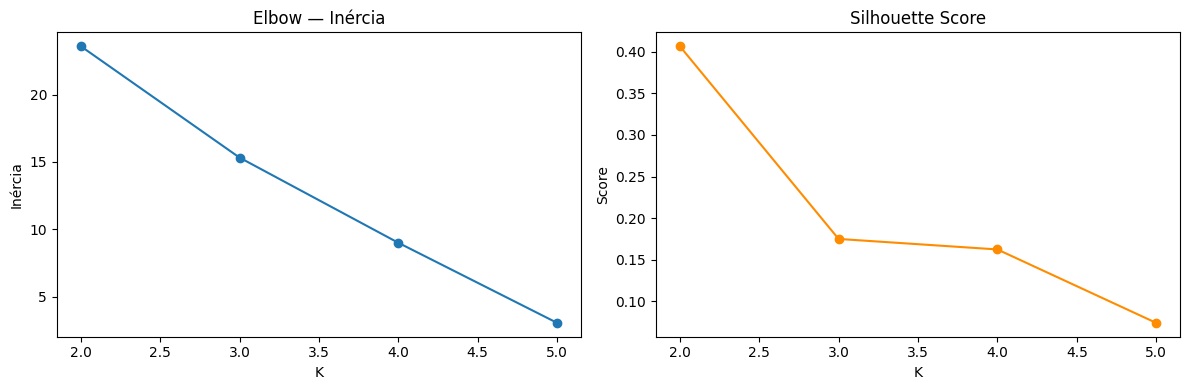

K sugerido pelo Silhouette: 2


In [54]:
evaluate_best_k(df_cluster_raw=df_cluster_reg, X_cluster=X_cluster)

In [55]:
#  Clustering final
K_FINAL = 2

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df_cluster_reg["Cluster"] = km_final.fit_predict(X_cluster)

print(df_cluster_reg[["Cluster"]].sort_values("Cluster"))

        Cluster
REGIAO         
Centro        0
Lisboa        0
Norte         0
Porto         0
Ilhas         1
Sul           1


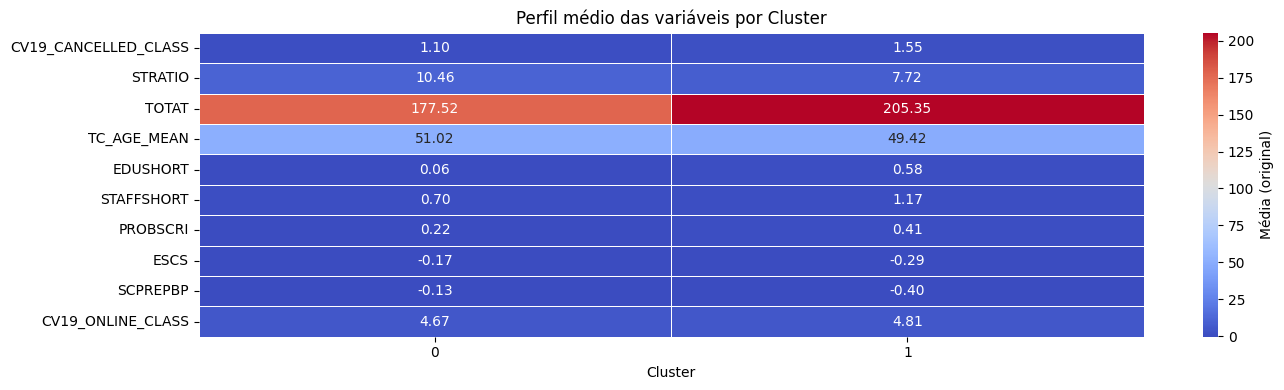

In [56]:
cluster_profile(df_cluster_raw=df_cluster_reg,top_vars=top_vars)

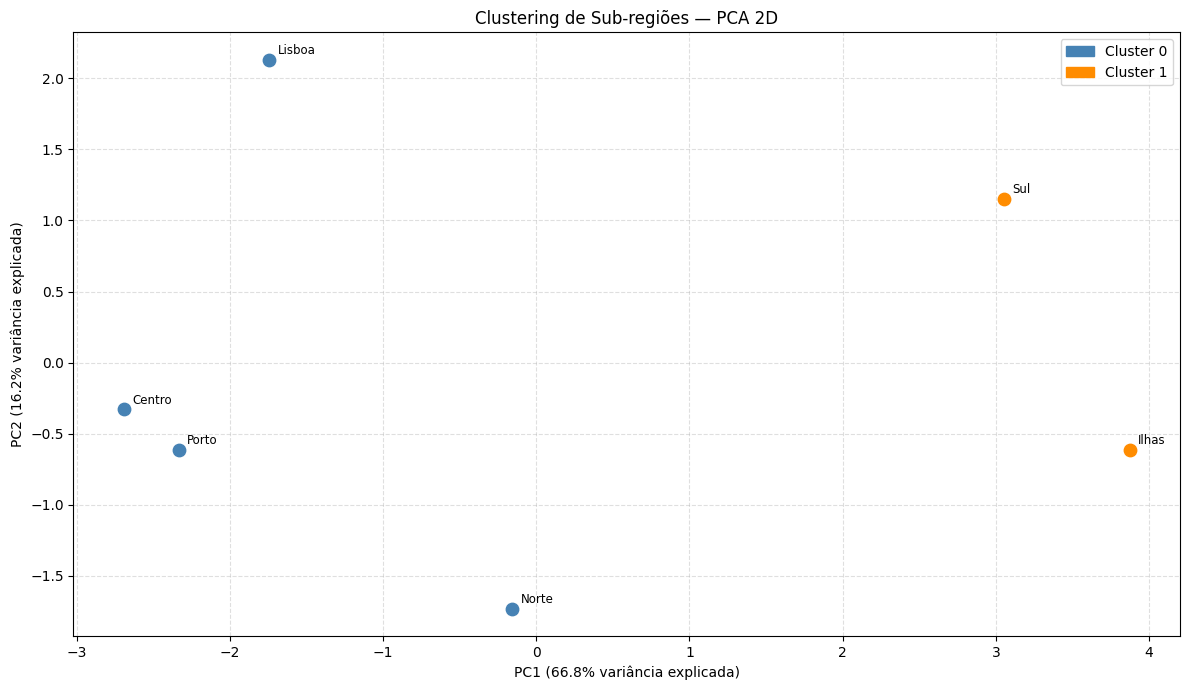

In [57]:
pca_graphic(df_cluster_reg,X_cluster=X_cluster)

### Por STRATUM

In [58]:
# ── Clustering por Zona ──────────────────────────────────────────────────────

# 1. Top N variáveis por |Explained| médio (excluindo constante e group_bin)
TOP_N = 10  # ajusta à vontade

top_vars = (
    resumo_stratum
    .drop(index=["const", "group_bin", "TOTAT"], errors="ignore")
    .sort_values("Explained", ascending=False)
    .head(TOP_N)
    .index.tolist()
)
print("Variáveis usadas no clustering:", top_vars)

Variáveis usadas no clustering: ['ICTRES', 'TC_AGE_MEAN', 'RELATST', 'FAMSUP', 'REPEAT', 'STRATIO', 'ESCS', 'EXERPRAC', 'SCPREPBP', 'CV19_ONLINE_CLASS']


In [59]:

group_col_stratum = "STRATUM"  # independente do group_col do Oaxaca

dt_std_pt["female"] = (dt_std_pt["STU_GENDER"] == 1).astype(int)

df_cluster_stratum = (
    dt_std_pt
    .dropna(subset=top_vars + [group_col_stratum])
    [top_vars + [group_col_stratum]]
    .groupby(group_col_stratum)
    .mean()
)

print(f"Zonas disponíveis ({len(df_cluster_stratum)}):", df_cluster_stratum.index.tolist())

scaler = StandardScaler()
X_cluster = scaler.fit_transform(df_cluster_stratum)

Zonas disponíveis (25): ['AM Lisboa', 'AM Porto', 'Alentejo Central', 'Alentejo Litoral', 'Algarve', 'Alto Alentejo', 'Alto Minho', 'Alto Tâmega', 'Ave', 'Baixo Alentejo', 'Beira Baixa', 'Beiras e Serra da Estrela', 'Cávado', 'Douro', 'Lezíria do Tejo', 'Médio Tejo', 'Oeste', 'R.A. Açores', 'R.A. Madeira', 'Região de Aveiro', 'Região de Coimbra', 'Região de Leiria', 'Terras de Trás-os-Montes', 'Tâmega e Sousa', 'Viseu Dão Lafões']


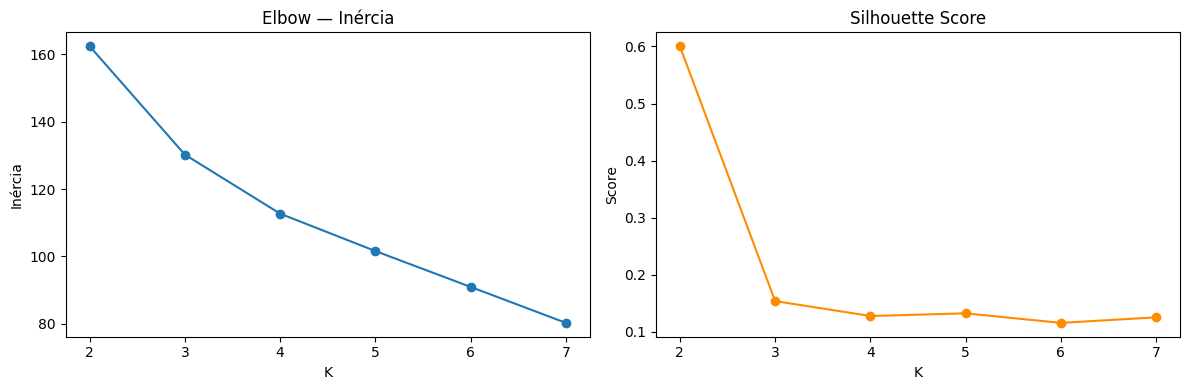

K sugerido pelo Silhouette: 2


In [60]:
evaluate_best_k(df_cluster_raw=df_cluster_stratum, X_cluster=X_cluster)

In [61]:
# 4. Clustering final
K_FINAL = 3

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df_cluster_stratum["Cluster"] = km_final.fit_predict(X_cluster)

print(df_cluster_stratum[["Cluster"]].sort_values("Cluster"))

                           Cluster
STRATUM                           
AM Lisboa                        0
AM Porto                         0
Alentejo Central                 0
Alentejo Litoral                 0
Alto Minho                       0
Ave                              0
Lezíria do Tejo                  0
Oeste                            0
Viseu Dão Lafões                 0
Região de Leiria                 0
Região de Coimbra                0
Baixo Alentejo                   1
Alto Tâmega                      1
Alto Alentejo                    1
Beira Baixa                      1
Algarve                          1
Médio Tejo                       1
Douro                            1
Cávado                           1
Beiras e Serra da Estrela        1
Região de Aveiro                 1
R.A. Madeira                     1
Tâmega e Sousa                   1
R.A. Açores                      1
Terras de Trás-os-Montes         2


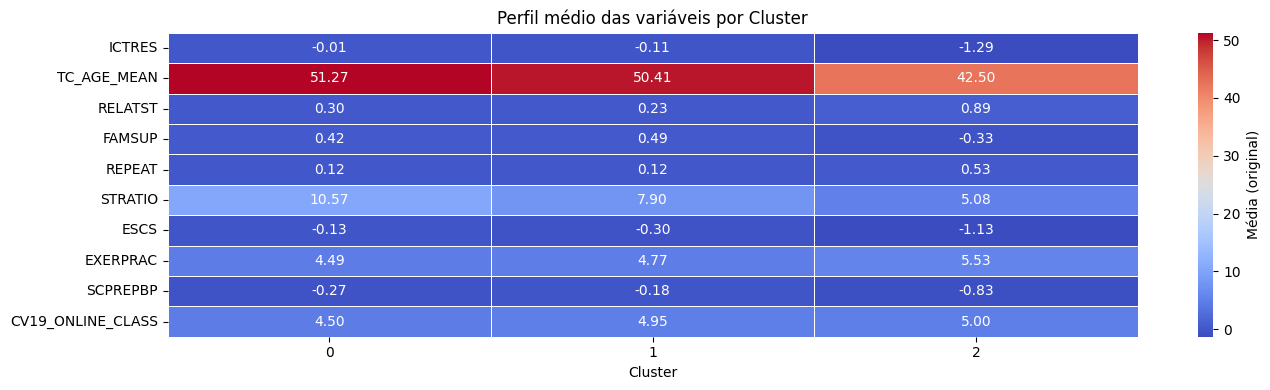

In [62]:
cluster_profile(df_cluster_raw=df_cluster_stratum,top_vars=top_vars)

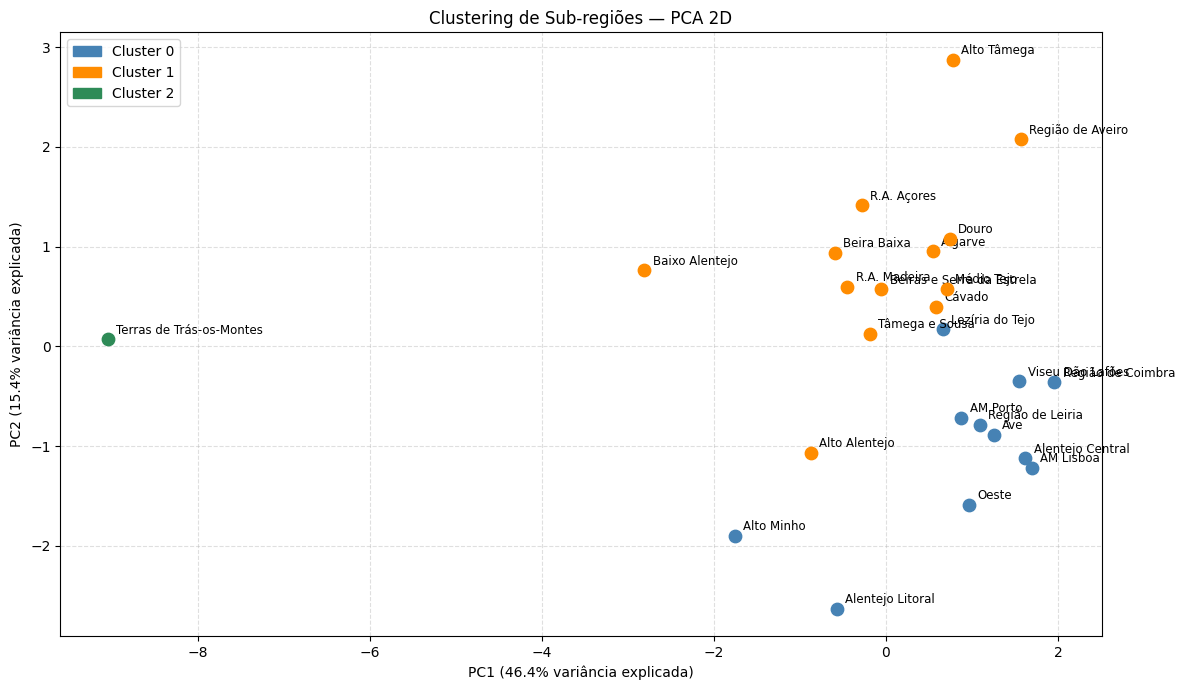

In [63]:
pca_graphic(df_cluster_stratum,X_cluster=X_cluster)

## Mapa de portugal

In [64]:
# NUTS III Portugal — fonte Eurostat (GISCO)
url = "https://gisco-services.ec.europa.eu/distribution/v2/nuts/geojson/NUTS_RG_20M_2021_4326.geojson"
nuts = gpd.read_file(url)

# filtrar Portugal, nível NUTS III
nuts_pt = nuts[(nuts["CNTR_CODE"] == "PT") & (nuts["LEVL_CODE"] == 3)].copy()

#print(nuts_pt[["NUTS_ID", "NUTS_NAME"]].to_string())

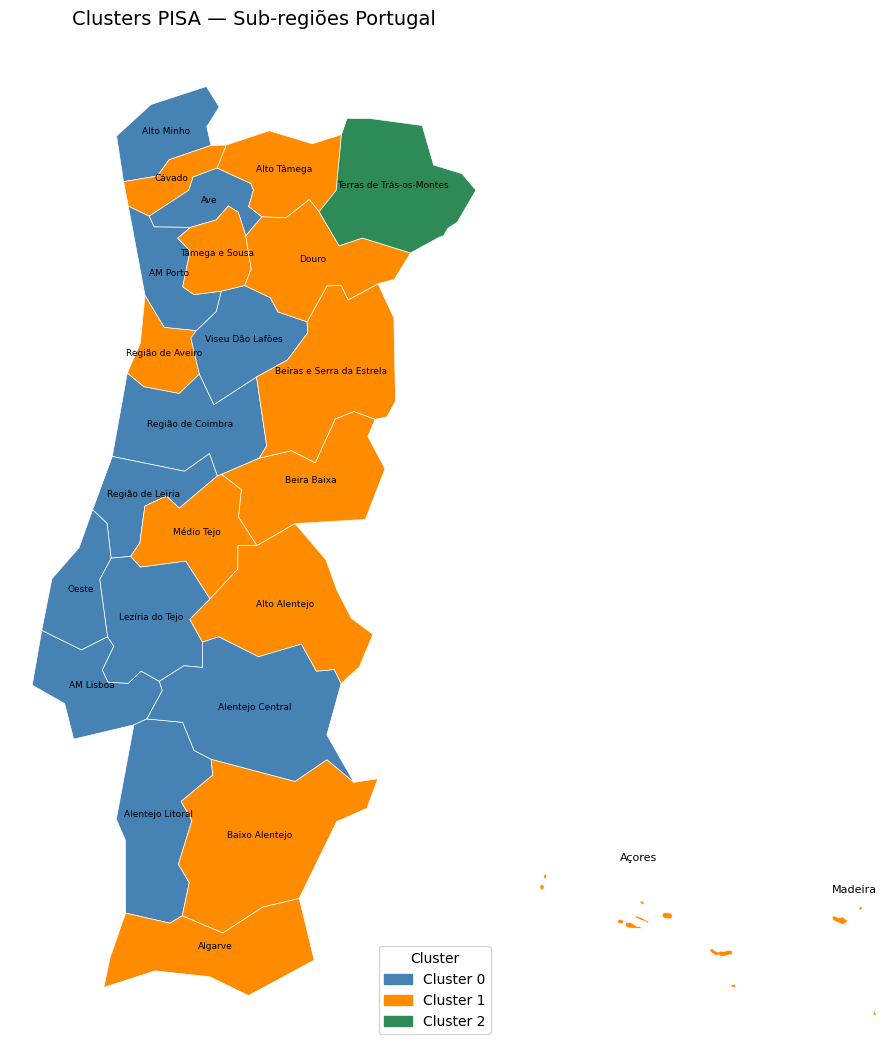

In [65]:
# mapeamento NUTS_NAME -> STRATUM
nome_map = {
    "Área Metropolitana de Lisboa": "AM Lisboa",
    "Área Metropolitana do Porto":  "AM Porto",
    "Alentejo Central":             "Alentejo Central",
    "Alentejo Litoral":             "Alentejo Litoral",
    "Algarve":                      "Algarve",
    "Alto Alentejo":                "Alto Alentejo",
    "Alto Minho":                   "Alto Minho",
    "Alto Tâmega":                  "Alto Tâmega",
    "Ave":                          "Ave",
    "Baixo Alentejo":               "Baixo Alentejo",
    "Beira Baixa":                  "Beira Baixa",
    "Beiras e Serra da Estrela":    "Beiras e Serra da Estrela",
    "Cávado":                       "Cávado",
    "Douro":                        "Douro",
    "Lezíria do Tejo":              "Lezíria do Tejo",
    "Médio Tejo":                   "Médio Tejo",
    "Oeste":                        "Oeste",
    "Região Autónoma dos Açores":   "R.A. Açores",
    "Região Autónoma da Madeira":   "R.A. Madeira",
    "Região de Aveiro":             "Região de Aveiro",
    "Região de Coimbra":            "Região de Coimbra",
    "Região de Leiria":             "Região de Leiria",
    "Terras de Trás-os-Montes":     "Terras de Trás-os-Montes",
    "Tâmega e Sousa":               "Tâmega e Sousa",
    "Viseu Dão Lafões":             "Viseu Dão Lafões",
}

# adicionar coluna STRATUM ao geodataframe
nuts_pt["STRATUM"] = nuts_pt["NUTS_NAME"].map(nome_map)

# juntar com os clusters
cluster_info = df_cluster_stratum[["Cluster"]].reset_index()
cluster_info.columns = ["STRATUM", "Cluster"]

nuts_plot = nuts_pt.merge(cluster_info, on="STRATUM", how="left")

# separar continente e ilhas
continente = nuts_plot[~nuts_plot["STRATUM"].isin(["R.A. Açores", "R.A. Madeira"])]
acores     = nuts_plot[nuts_plot["STRATUM"] == "R.A. Açores"]
madeira    = nuts_plot[nuts_plot["STRATUM"] == "R.A. Madeira"]

# cores por cluster
n_clusters = df_cluster_stratum["Cluster"].nunique()
palette = ["steelblue", "darkorange", "seagreen", "crimson", "purple", "brown"]
cmap_vals = {c: palette[c] for c in range(n_clusters)}
nuts_plot["color"] = nuts_plot["Cluster"].map(cmap_vals)

fig = plt.figure(figsize=(12, 10))

# continente
ax_main = fig.add_axes([0.0, 0.0, 0.78, 1.0])
continente.assign(color=continente["Cluster"].map(cmap_vals)).plot(
    color=continente["Cluster"].map(cmap_vals),
    edgecolor="white", linewidth=0.5, ax=ax_main
)
# labels
for _, row in continente.iterrows():
    if row.geometry and not row.geometry.is_empty:
        ax_main.annotate(row["STRATUM"],
                         xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                         fontsize=6.5, ha="center", color="black")

ax_main.set_axis_off()
ax_main.set_title("Clusters PISA — Sub-regiões Portugal", fontsize=14, pad=12)

# açores (canto inferior esquerdo)
ax_ac = fig.add_axes([0.62, 0.02, 0.18, 0.18])
acores.plot(color=acores["Cluster"].map(cmap_vals),
            edgecolor="white", linewidth=0.5, ax=ax_ac)
ax_ac.set_axis_off()
ax_ac.set_title("Açores", fontsize=8)

# madeira (canto inferior, ao lado)
ax_mad = fig.add_axes([0.80, 0.02, 0.18, 0.12])
madeira.plot(color=madeira["Cluster"].map(cmap_vals),
             edgecolor="white", linewidth=0.5, ax=ax_mad)
ax_mad.set_axis_off()
ax_mad.set_title("Madeira", fontsize=8)

# legenda
patches = [mpatches.Patch(color=palette[c], label=f"Cluster {c}")
           for c in range(n_clusters)]
ax_main.legend(handles=patches, loc="lower right", fontsize=10,
               title="Cluster", title_fontsize=10)

plt.show()